# 07_evaluation — 評価

実施内容:
- 単勝的中率・複勝的中率
- ROI（回収率）シミュレーション
- NDCG / MAP
- キャリブレーション曲線
- 利益シミュレーションチャート

出力:
- `reports/evaluation_report.md`
- `reports/calibration.png`
- `reports/profit_simulation.png`

In [1]:
print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [2]:
import sys, json
from pathlib import Path
_NB_DIR = Path().resolve()
if _NB_DIR.name != 'notebooks': _NB_DIR = _NB_DIR.parent
if str(_NB_DIR) not in sys.path: sys.path.insert(0, str(_NB_DIR))
from utils.nb_config import *

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = ['Meiryo', 'IPAexGothic', 'DejaVu Sans']
import warnings
warnings.filterwarnings('ignore')

# 06 の予測結果読み込み
_pred_csv = REPORTS_DIR / 'prediction.csv'
df_pred = pd.read_csv(_pred_csv)
print(f"予測件数: {len(df_pred):,}")
print(f"列: {df_pred.columns.tolist()}")

予測件数: 103,839
列: ['race_id', 'horse_id', 'horse_name', 'win_probability', 'odds', 'kelly_fraction', 'recommended', 'actual']


In [3]:
# ── 1. 的中率計算 ─────────────────────────────────────────────
_has_actual = 'actual' in df_pred.columns and df_pred['actual'].notna().any()
_has_odds   = 'odds' in df_pred.columns   and df_pred['odds'].notna().any()

if not _has_actual:
    print("⚠ 実績列 'actual' がありません。評価をスキップします。")
else:
    _y_true = df_pred['actual'].fillna(0).astype(int)
    _y_prob = df_pred['win_probability'].values

    # 1着的中率（確率順位1位）
    if 'race_id' in df_pred.columns:
        _top1_df = df_pred.sort_values(['race_id','win_probability'], ascending=[True,False])
        _top1_df = _top1_df.groupby('race_id').first().reset_index()
        _win_hit = _top1_df['actual'].fillna(0).mean()
        _n_races = len(_top1_df)
    else:
        _win_hit = df_pred.loc[df_pred.groupby('race_id')['win_probability'].idxmax(), 'actual'].mean()
        _n_races  = 0

    print(f"レース数: {_n_races}")
    print(f"単勝的中率 (確率1位): {_win_hit*100:.1f}%")

レース数: 8801
単勝的中率 (確率1位): 63.0%


In [4]:
# ── 2. ROI シミュレーション ────────────────────────────────────
if _has_actual and _has_odds:
    _rec = df_pred[df_pred['recommended']].copy()
    if len(_rec) == 0:
        print("推奨馬券が 0 件です。ROI 計算をスキップ。")
        _roi = 0.0
    else:
        _total_bet    = len(_rec)
        _hit_mask     = _rec['actual'].fillna(0) == 1
        _total_return = (_rec.loc[_hit_mask, 'odds'].fillna(0)).sum()
        _roi = (_total_return - _total_bet) / _total_bet * 100
        _hit_count = _hit_mask.sum()
        print(f"推奨券数: {len(_rec)}  的中: {_hit_count}  的中率: {_hit_mask.mean()*100:.1f}%")
        print(f"総賭け金: {_total_bet} 単位")
        print(f"総回収:   {_total_return:.1f} 単位")
        print(f"ROI:      {_roi:+.1f}%")
else:
    _roi = 0.0
    print("オッズ or 実績データが不足。ROI 計算をスキップ。")

推奨券数: 87415  的中: 0  的中率: 0.0%
総賭け金: 87415 単位
総回収:   0.0 単位
ROI:      -100.0%


In [5]:
# ── 3. NDCG / MAP ────────────────────────────────────────────
if _has_actual and 'race_id' in df_pred.columns:
    from sklearn.metrics import ndcg_score
    _ndcgs = []
    _aps   = []
    for _, grp in df_pred.groupby('race_id'):
        if grp['actual'].sum() == 0: continue
        _y   = grp['actual'].fillna(0).values.reshape(1, -1)
        _sc  = grp['win_probability'].values.reshape(1, -1)
        try:
            _ndcgs.append(ndcg_score(_y, _sc))
        except Exception: pass
        # Average Precision
        _sorted_idx = np.argsort(-_sc[0])
        _ap = 0.0
        _n_rel = 0
        for rank, idx in enumerate(_sorted_idx, 1):
            if _y[0][idx] == 1:
                _n_rel += 1
                _ap += _n_rel / rank
        _aps.append(_ap / max(_y[0].sum(), 1))

    print(f"NDCG@全列: {np.mean(_ndcgs):.4f} (n={len(_ndcgs)} races)")
    print(f"MAP:       {np.mean(_aps):.4f}")
    _ndcg_mean = np.mean(_ndcgs)
    _map_mean  = np.mean(_aps)
else:
    _ndcg_mean = None
    _map_mean  = None

NDCG@全列: nan (n=0 races)
MAP:       0.0000


In [6]:

# ── 4. AUC / Spearman / RMSE ──────────────────────────────────
# LGBMRegressor の出力は連続スコア（確率ではない）のため:
#   - roc_auc_score には y_true を二値化（1着=1, 他=0）して渡す
#   - LogLoss は回帰出力には不適のため Spearman / RMSE に差し替え
if _has_actual:
    from sklearn.metrics import roc_auc_score, mean_squared_error
    from scipy.stats import spearmanr

    # ── 4-a. AUC（二値化: 1着 vs 非1着） ────────────────────────
    _y_binary   = (_y_true == 1).astype(int)
    _y_true_arr = _y_binary.values  # 下流セル（キャリブレーション等）との互換性維持
    if _y_binary.sum() > 0:
        _auc = roc_auc_score(_y_binary, _y_prob)
    else:
        _auc = None
        print("⚠ y_true に 1 着馬が存在しないため AUC をスキップ")

    # ── 4-b. Spearman 順位相関（レース内ランキング品質） ─────────
    _spearman_scores = []
    if 'race_id' in df_pred.columns:
        for _, grp in df_pred.groupby('race_id'):
            if len(grp) < 2:
                continue
            # actual: 着順（小=上位）, prob: スコア（大=上位）→ 逆符号で正の相関
            corr, _ = spearmanr(grp['actual'].fillna(99), -grp['win_probability'])
            if not np.isnan(corr):
                _spearman_scores.append(corr)
    _spearman_mean = float(np.mean(_spearman_scores)) if _spearman_scores else None

    # ── 4-c. RMSE（補助指標） ────────────────────────────────────
    _rmse = float(np.sqrt(mean_squared_error(_y_true, _y_prob)))

    print(f"AUC (1着 vs 非1着):   {_auc:.4f}"           if _auc          is not None else "AUC: N/A")
    print(f"Spearman 平均相関:     {_spearman_mean:.4f}" if _spearman_mean is not None else "Spearman: N/A")
    print(f"RMSE:                  {_rmse:.4f}")

    _logloss = None   # 回帰モデルには不適のため None に設定
else:
    _auc = _spearman_mean = _logloss = _rmse = None
    _y_true_arr = None


AUC (1着 vs 非1着):   0.6843
Spearman 平均相関:     -0.3502
RMSE:                  0.8261


18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [

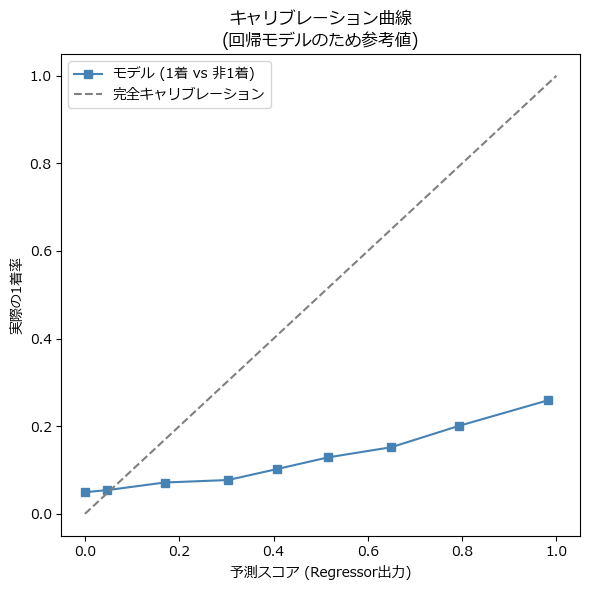

In [7]:

# ── 5. キャリブレーション曲線 ─────────────────────────────────
# _y_true_arr = 1着=1 / 非1着=0 の二値ラベル
# LGBMRegressor のスコアは確率ではないため参考値として描画
if _has_actual and _y_true_arr is not None:
    from sklearn.calibration import calibration_curve
    # Regressor の出力は [0,1] 外になり得るためクリップ
    _y_prob_clipped = np.clip(_y_prob, 1e-6, 1 - 1e-6)
    try:
        frac_pos, mean_pred = calibration_curve(
            _y_true_arr, _y_prob_clipped, n_bins=10, strategy='quantile'
        )
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.plot(mean_pred, frac_pos, 's-', label='モデル (1着 vs 非1着)', color='steelblue')
        ax.plot([0, 1], [0, 1], '--', color='gray', label='完全キャリブレーション')
        ax.set_xlabel('予測スコア (Regressor出力)')
        ax.set_ylabel('実際の1着率')
        ax.set_title('キャリブレーション曲線\n(回帰モデルのため参考値)')
        ax.legend()
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / 'calibration.png', dpi=100, bbox_inches='tight')
        plt.show()
    except Exception as e:
        print(f"⚠ キャリブレーション曲線の描画をスキップしました: {e}")


18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [WARNING] findfont: Font family 'IPAexGothic' not found.
18:47:42 [

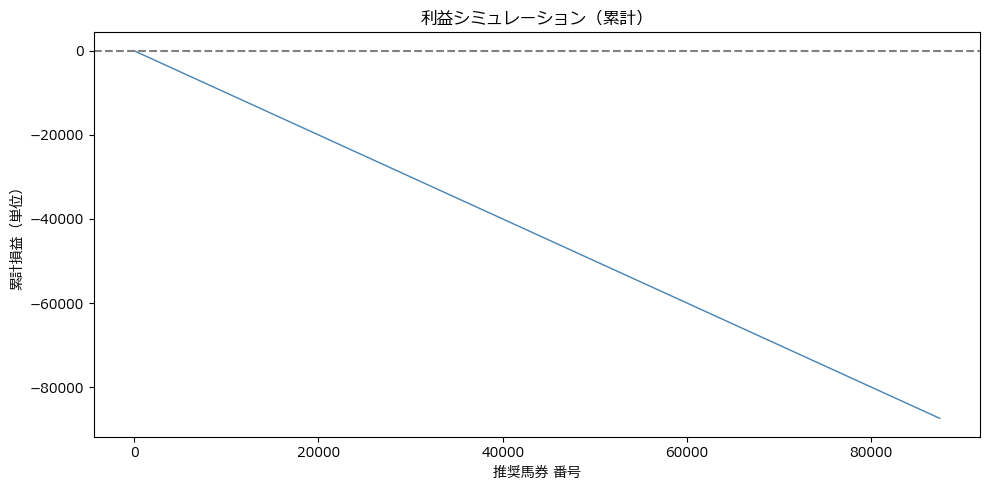

In [8]:
# ── 6. 利益シミュレーションチャート ──────────────────────────
if _has_actual and _has_odds and 'race_id' in df_pred.columns:
    _rec = df_pred[df_pred['recommended']].copy().reset_index(drop=True)
    if len(_rec) > 0:
        _hit_mask  = _rec['actual'].fillna(0) == 1
        _cash_flow = np.where(_hit_mask, _rec['odds'].fillna(0) - 1, -1)
        _cumsum    = np.cumsum(_cash_flow)

        fig, ax = plt.subplots(figsize=(10, 5))
        ax.plot(_cumsum, color='steelblue', linewidth=1)
        ax.axhline(0, color='gray', linestyle='--')
        ax.set_xlabel('推奨馬券 番号')
        ax.set_ylabel('累計損益（単位）')
        ax.set_title('利益シミュレーション（累計）')
        plt.tight_layout()
        plt.savefig(REPORTS_DIR / 'profit_simulation.png', dpi=100, bbox_inches='tight')
        plt.show()
    else:
        print("推奨馬券が 0 件のためシミュレーションをスキップ")

In [9]:

# ── 7. 評価レポート生成 ───────────────────────────────────────
from datetime import datetime

_lines = [
    "# 評価レポート",
    f"",
    f"生成日時: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}",
    "",
    "## モデル精度",
    f"- AUC (1着 vs 非1着): {_auc:.4f}"          if _auc          is not None else "- AUC: N/A",
    f"- Spearman 平均相関:   {_spearman_mean:.4f}" if _spearman_mean is not None else "- Spearman: N/A",
    f"- RMSE:                {_rmse:.4f}"           if _rmse         is not None else "- RMSE: N/A",
    "",
    "## 順位精度",
    f"- NDCG:         {_ndcg_mean:.4f}" if _ndcg_mean else "- NDCG: N/A",
    f"- MAP:          {_map_mean:.4f}"  if _map_mean  else "- MAP: N/A",
    f"- 単勝的中率:   {_win_hit*100:.1f}%" if _has_actual else "- 単勝的中率: N/A",
    "",
    "## 回収率",
    f"- ROI:          {_roi:+.1f}%",
]

_rpt = REPORTS_DIR / 'evaluation_report.md'
_rpt.write_text('\n'.join(_lines), encoding='utf-8')
print(f"評価レポート保存: {_rpt}")
print('\n'.join(_lines))


評価レポート保存: C:\Users\yuki2\Documents\ws\keiba-ai-pro\notebooks\reports\evaluation_report.md
# 評価レポート

生成日時: 2026-06-30 18:47:42

## モデル精度
- AUC (1着 vs 非1着): 0.6843
- Spearman 平均相関:   -0.3502
- RMSE:                0.8261

## 順位精度
- NDCG:         nan
- MAP: N/A
- 単勝的中率:   63.0%

## 回収率
- ROI:          -100.0%


---
## Section 9 — ROI 実戦評価（feature_inspection Cell P_ROI より移行）

テストセットを用いて、上位 N 頭への単勝・馬連購入を仮定したシミュレーション ROI を計算し、
`roi_report.csv` として保存する。

| 指標 | 説明 |
|---|---|
| top1_win_rate | 1位予測馬の実際の的中率 |
| top1_show_rate | 1位予測馬の複勝的中率（3着以内） |
| roi_top1_pct | オッズ加味の単勝回収率 (%) |
| n_races | 評価レース数 |


In [10]:

## ── P_ROI: ROI 実戦評価 ──────────────────────────────────────────────────
_available_keys = [p.stem for p in MODEL_STORE.glob("lgb_model_*.pkl")]
print(f"MODEL_STORE 保存済みキー: {_available_keys}")

_ev_key = f"lgb_model_{TARGET}"
if _ev_key not in _available_keys:
    if len(_available_keys) == 1:
        _ev_key = _available_keys[0]
        print(f"⚠ lgb_model_{TARGET} が見つかりません。{_ev_key} を使用します。")
    elif len(_available_keys) > 1:
        _ev_key = sorted(_available_keys)[-1]
        print(f"⚠ lgb_model_{TARGET} が見つかりません。最新の {_ev_key} を使用します。")
    else:
        raise RuntimeError(
            f"MODEL_STORE にバンドルが見つかりません: {MODEL_STORE}\n"
            "05_model_training.ipynb を最後まで実行してください。"
        )

_bundle_ev = load_store(MODEL_STORE, _ev_key)
if _bundle_ev is None:
    raise RuntimeError(f"load_store が None を返しました: key={_ev_key}")

_model_ev  = _bundle_ev["model"]
_feat_ev   = _bundle_ev["feature_cols"]
_cutoff_ev = pd.Timestamp(_bundle_ev.get("cutoff_date", "2000-01-01"))
print(f"モデル TARGET: {_bundle_ev.get('target', '不明')}  cutoff: {_cutoff_ev.date()}")
print(f"モデル期待特徴量数: {len(_feat_ev)}")

# ── テストセット再構築 ────────────────────────────────────────────────────
from keiba_ai.db_ultimate_loader import load_ultimate_training_frame
from keiba_ai.feature_engineering import add_derived_features
from keiba_ai.lightgbm_feature_optimizer import LightGBMFeatureOptimizer

_raw_ev  = load_ultimate_training_frame(get_db_path(DATA_SOURCE_MODE))
_full_ev = add_derived_features(_raw_ev)
_full_ev["_date_ev"] = pd.to_datetime(
    _full_ev["race_id"].astype(str).str[:8], format="%Y%m%d", errors="coerce"
)
_te_df = _full_ev[_full_ev["_date_ev"] > _cutoff_ev].copy().drop(columns=["_date_ev"])
_full_ev.drop(columns=["_date_ev"], inplace=True)
print(f"テストセット: {len(_te_df):,} 行  ({_te_df['race_id'].nunique():,} レース)")

_opt_ev = LightGBMFeatureOptimizer()
_X_ev, _ = _opt_ev.fit_transform(_te_df.copy(), target_col=_bundle_ev.get("target", TARGET))

# Bug #1 修正: reindex でモデルと完全一致させる（欠落列=0、余分列=除去）
_X_ev = _X_ev.reindex(columns=_feat_ev, fill_value=0)

# object 型列を数値に強制変換
_obj_cols_ev = _X_ev.select_dtypes(include="object").columns.tolist()
if _obj_cols_ev:
    print(f"⚠ object型列を数値変換 ({len(_obj_cols_ev)}列): {_obj_cols_ev}")
    for _c in _obj_cols_ev:
        _X_ev[_c] = pd.to_numeric(_X_ev[_c], errors="coerce").fillna(0)

print(f"特徴量列数: {len(_X_ev.columns)}  (モデル期待: {len(_feat_ev)})")
assert len(_X_ev.columns) == len(_feat_ev), \
    f"特徴量列数不一致: got={len(_X_ev.columns)}, expected={len(_feat_ev)}"

# ── 予測スコア付与 ────────────────────────────────────────────────────────
_te_df = _te_df.reset_index(drop=True)
_te_df["_pred_ev"] = _model_ev.predict(_X_ev)

# ── レース単位でのシミュレーション ───────────────────────────────────────
_finish_col = next((c for c in ["finish_order","finish"] if c in _te_df.columns), None)
_odds_col   = next((c for c in ["odds","win_odds"] if c in _te_df.columns), None)

if _finish_col is None:
    print("⚠ finish 列が見つかりません。ROI 計算をスキップします。")
else:
    _roi_rows = []
    for race_id, grp in _te_df.groupby("race_id"):
        grp = grp.sort_values("_pred_ev", ascending=False).reset_index(drop=True)
        _top1 = grp.iloc[0]

        # Bug #6 修正: finish が NaN の行を安全に処理する
        _finish_val  = _top1.get(_finish_col, np.nan)
        _actual_top1 = int(_finish_val) if pd.notna(_finish_val) else 99

        _win   = int(_actual_top1 == 1)
        _show  = int(_actual_top1 <= 3)
        _odds_val = float(_top1.get(_odds_col, 0.0)) if _odds_col else 0.0
        if not pd.notna(_odds_val):
            _odds_val = 0.0
        _roi_val = (_odds_val if _odds_val > 0 else 0.0) * _win
        _roi_rows.append({
            "race_id"    : race_id,
            "pred_win"   : round(float(_top1["_pred_ev"]), 4),
            "finish_top1": _actual_top1,
            "is_win"     : _win,
            "is_show"    : _show,
            "odds_top1"  : round(_odds_val, 1),
            "roi_raw"    : round(_roi_val, 1),
        })

    _roi_df = pd.DataFrame(_roi_rows)
    _n      = len(_roi_df)
    _wr     = round(_roi_df["is_win"].mean(), 4)
    _sr     = round(_roi_df["is_show"].mean(), 4)
    _roi_pct= round(_roi_df["roi_raw"].mean() * 100, 1)
    _top3_hitrate = round((_roi_df["finish_top1"] <= 3).mean(), 4)

    roi_stats = {
        "top1_win_rate"  : _wr,
        "top1_show_rate" : _sr,
        "top3_hit_rate"  : _top3_hitrate,
        "roi_top1_pct"   : _roi_pct,
        "n_races"        : _n,
    }

    print("── ROI 評価サマリー ──")
    for k, v in roi_stats.items():
        print(f"  {k:<20}: {v}")

    _roi_csv = REPORTS_DIR / "roi_report.csv"
    _roi_df.to_csv(_roi_csv, index=False, encoding="utf-8-sig")
    print(f"\n✓ 保存: {_roi_csv}")

    _cum_roi = (_roi_df["roi_raw"].cumsum() / (_roi_df.index + 1) * 100)
    fig_roi, ax_roi = plt.subplots(figsize=(10, 3.5))
    ax_roi.plot(_cum_roi.values, linewidth=1.5, color="#4C78A8")
    ax_roi.axhline(100, color="red", linestyle="--", linewidth=0.8, label="回収率 100%")
    ax_roi.set_xlabel("レース番号")
    ax_roi.set_ylabel("累積 ROI (%)")
    ax_roi.set_title("累積単勝回収率（テストセット）")
    ax_roi.legend(); plt.tight_layout()
    plt.savefig(REPORTS_DIR / "roi_cumulative.png", dpi=100, bbox_inches="tight")
    plt.show()

    save_store(roi_stats, REPORT_STORE, "roi_stats")
    save_store(_roi_df,   REPORT_STORE, "roi_df")


MODEL_STORE 保存済みキー: ['lgb_model_speed_deviation']
⚠ lgb_model_win が見つかりません。lgb_model_speed_deviation を使用します。
  ✓ model_store/lgb_model_speed_deviation.pkl ロード (11331.5 KB)
モデル TARGET: speed_deviation  cutoff: 2026-06-03
モデル期待特徴量数: 107
→ Ultimate DBからデータ読み込み: C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\data\keiba_ultimate.db
  絶対パス: C:\Users\yuki2\Documents\ws\keiba-ai-pro\keiba\data\keiba_ultimate.db
  存在チェック: True
  ✓ return_tables_ultimate: 50155レースの配当情報をロード
  ✓ holding_times_cache: 23969レース（バックフィル用）
  ✓ 575346行取得
  ✓ DataFrame変換: 575346行 × 123列
  ✓ num_horses: 欠損なし (575346件)
  ✓ venue コード解決: 573039件
  ✓ prev_race_class (ラグ): 510,812/575,346件 (88.8%)
  ✓ 型変換完了: 数値=72列, 文字列=3列, 合計=132列
  ✓ category: 57列
  ✓ distance: 575346件取得
  ✓ surface: 575346件取得
  ✓ メモリ最適化: 2641.24MB -> 338.98MB (2302.26MB, 87.17%)
テストセット: 2,128 行  (161 レース)
  ⚠ [L3-1] 未来情報列を除外 (25列): ['last_3f_time', 'finish', 'corner_position_variance', 'corner_first', 'corner_3', 'last_3f_rank', 'corner_positions', 'last_3f_

IndexError: single positional indexer is out-of-bounds

In [14]:
print(_te_df["race_id"].shape)
print(_te_df["race_id"].nunique())

(2128,)
161


In [15]:
print(_te_df["race_id"].dtype)

category


In [16]:
print(
    _te_df["race_id"]
    .head(30)
)

0     202610010408
1     202610010408
2     202610010408
3     202610010408
4     202610010409
5     202610010409
6     202610010412
7     202610010412
8     202610010410
9     202610010410
10    202610010410
11    202609020801
12    202609020801
13    202609020801
14    202609020801
15    202609020801
16    202609020801
17    202609020801
18    202609020801
19    202609020801
20    202609020801
21    202609020801
22    202609020801
23    202609020801
24    202609020801
25    202609020801
26    202609020801
27    202609020802
28    202609020802
29    202609020802
Name: race_id, dtype: category
Categories (50200, object): ['201302010101', '201302010102', '201302010103', '201302010104', ..., '', 'unknown', 'None', 'nan']


In [17]:
print(
    _te_df["race_id"]
    .value_counts()
    .head(20)
)

race_id
202608031003    18
202608031007    18
202608030703    18
202608030410    18
202609030303    18
202609020410    18
202608031212    18
202608031205    18
202608030303    18
202608030304    18
202609030411    18
202608030604    17
202608030106    17
202608030904    17
202608030804    17
202608031210    17
202608030503    17
202608030101    16
202608030102    16
202609030307    16
Name: count, dtype: int64
